# Notebook 03 — Abrupt Drift Detection: OCSVM vs Isolation Forest
### Population Drift in Deployed AI Medical Devices
**Cohorts:** Pima Indians Diabetes (n=768) · Frankfurt Hospital Glucose Dataset (n=2,000)

**Drift type:** Abrupt affine (Min-Max) transformation — shift factor δ=0.4, range factor σ=1.5  
**Scenarios:** Univariate (Glucose only) · Multivariate (Glucose + BMI + Age)  
**Algorithms:** Isolation Forest (contamination=0.2) · OCSVM (ν=0.2, γ=scale)  
**Validation:** K-S tests + SHAP KernelExplainer feature attribution

> ⚠️ SHAP KernelExplainer is computationally intensive — expect several minutes per dataset/model combination.

In [1]:
# ================================================================
# IMPORTS
# ================================================================
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')
print("All imports successful.")

All imports successful.


In [3]:
# ================================================================
# CONFIGURATION
# ================================================================
DATASET_CONFIGS = {
    'Pima': {
        'step1_path': Path('data/interim/pima_step1_clean.csv'),
        'label'     : 'Pima Indians (n=768)',
    },
    'FHGD': {
        'step1_path': Path('data/interim/fhgd_step1_clean.csv'),
        'label'     : 'Frankfurt Hospital (n=2,000)',
    },
}

RESULTS_DIR  = Path('data/results')
REPORTS_DIR  = Path('reports/abrupt_drift')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

DRIFT_FEATURES_MULTI = ['Glucose', 'BMI', 'Age']
COLS_WITH_MISSING    = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Affine drift parameters (fixed — matches paper)
SHIFT_FACTOR = 0.4   # 60% downward location shift
RANGE_FACTOR = 1.5   # 50% variance expansion

print(f'Abrupt drift params: shift_factor={SHIFT_FACTOR}, range_factor={RANGE_FACTOR}')

Abrupt drift params: shift_factor=0.4, range_factor=1.5


In [4]:
# ================================================================
# SECTION 0 — SHARED UTILITY FUNCTIONS
# ================================================================

# ── Preprocessing (identical to NB-02) ───────────────────────────
def preprocess_dataset(step1_path):
    """Load, flag, 70/30 split, impute+scale on baseline only."""
    df = pd.read_csv(step1_path)
    for col in COLS_WITH_MISSING:
        df[f'{col}_is_missing'] = df[col].isna().astype(int)

    X = df.drop(columns='Outcome').sort_index()
    y = df['Outcome'].sort_index()
    sp = int(0.7 * len(X))

    X_base_raw = X.iloc[:sp].copy()
    X_test_raw = X.iloc[sp:].copy()

    indicator_cols  = [c for c in X_base_raw.columns if c.endswith('_is_missing')]
    continuous_cols = [c for c in X_base_raw.columns if c not in indicator_cols]

    imputer = SimpleImputer(strategy='median')
    scaler  = StandardScaler()
    imputer.set_output(transform='pandas')
    scaler.set_output(transform='pandas')

    imputer.fit(X_base_raw[continuous_cols])
    X_base_imp = imputer.transform(X_base_raw[continuous_cols])
    scaler.fit(X_base_imp)
    X_base_sc  = scaler.transform(X_base_imp)
    X_base_scaled = pd.concat([X_base_sc, X_base_raw[indicator_cols]], axis=1)

    X_test_imp = imputer.transform(X_test_raw[continuous_cols])
    X_test_sc  = scaler.transform(X_test_imp)
    X_test_scaled = pd.concat([X_test_sc, X_test_raw[indicator_cols]], axis=1)

    return dict(X_base_raw=X_base_raw, X_test_raw=X_test_raw,
                X_base_scaled=X_base_scaled, X_test_scaled=X_test_scaled,
                imputer=imputer, scaler=scaler,
                indicator_cols=indicator_cols, continuous_cols=continuous_cols,
                y_test=y.iloc[sp:].copy(), n_total=len(df))


# ── Baseline statistics for affine drift ─────────────────────────
def compute_base_stats(X_base_raw, features):
    """Compute f_min and f_range from baseline raw data for affine transformation."""
    stats = {}
    for feat in features:
        f_min   = np.nanmin(X_base_raw[feat])
        f_max   = np.nanmax(X_base_raw[feat])
        stats[feat] = {'f_min': f_min, 'f_range': f_max - f_min}
        print(f'  {feat}: f_min={f_min:.3f}, f_max={f_max:.3f}')
    return stats


# ── Affine drift function ─────────────────────────────────────────
def apply_minmax_drift(X_data, base_stats, features, shift_f, range_f, verbose=True):
    """Apply Min-Max affine transformation to simulate abrupt population shock.

    Formula: x_drifted = ((x - f_min) / f_range) * (max_t - min_t) + min_t
    where min_t = f_min * shift_f  and  max_t = min_t + f_range * range_f
    All stats derived from BASELINE to preserve no-leakage guarantee.
    """
    X_d = X_data.copy()
    if verbose:
        print(f'\nAffine drift: shift_factor={shift_f}, range_factor={range_f}')
        print(f'Features: {features}')

    for feat in features:
        if feat not in X_d.columns:
            print(f'  Warning: {feat} not found, skipping.'); continue
        if feat not in base_stats:
            print(f'  Error: no baseline stats for {feat}, skipping.'); continue

        f_min   = base_stats[feat]['f_min']
        f_range = base_stats[feat]['f_range']
        if f_range == 0:
            print(f'  Warning: {feat} has zero range, skipping.'); continue

        min_t = f_min * shift_f
        max_t = min_t + f_range * range_f

        orig    = X_d[feat].copy()
        new_val = orig.copy()
        mask    = ~np.isnan(orig)

        normalized       = (orig[mask] - f_min) / f_range
        new_val[mask]    = normalized * (max_t - min_t) + min_t
        X_d[feat]        = new_val

        if verbose:
            orig_mean = np.nanmean(orig); new_mean = np.nanmean(new_val)
            orig_std  = np.nanstd(orig);  new_std  = np.nanstd(new_val)
            ms = (new_mean/orig_mean - 1)*100 if orig_mean != 0 else 0
            ss = (new_std /orig_std  - 1)*100 if orig_std  != 0 else 0
            print(f'  {feat}: mean {orig_mean:.2f}->{new_mean:.2f} ({ms:+.1f}%)  '
                  f'std {orig_std:.2f}->{new_std:.2f} ({ss:+.1f}%)')
    return X_d


# ── Pipeline helper ───────────────────────────────────────────────
def apply_pipeline(X_raw_drifted, data):
    """Impute then scale drifted raw data using baseline-fitted transformers."""
    c_c = data['continuous_cols']; i_c = data['indicator_cols']
    imp = data['imputer'];         sc  = data['scaler']
    X_imp = imp.transform(X_raw_drifted[c_c])
    X_sc  = pd.DataFrame(sc.transform(X_imp), columns=c_c, index=X_raw_drifted.index)
    return pd.concat([X_sc, X_raw_drifted[i_c]], axis=1)


# ── Detection ratio ───────────────────────────────────────────────
def compute_dr(model, X_baseline_scaled, X_drifted_scaled, label=''):
    """Compute anomaly rates and detection ratio vs zero-drift control on undrifted test set."""
    base_preds    = model.predict(X_baseline_scaled)
    drifted_preds = model.predict(X_drifted_scaled)
    base_rate     = (base_preds == -1).mean()
    drifted_rate  = (drifted_preds == -1).mean()
    dr = drifted_rate / base_rate if base_rate > 0 else np.nan
    if label:
        print(f'  [{label}] baseline={base_rate:.1%}  drifted={drifted_rate:.1%}  DR={dr:.3f}x')
    return dict(baseline_rate=base_rate, drifted_rate=drifted_rate, detection_ratio=dr)


# ── K-S validation ────────────────────────────────────────────────
def run_ks_tests(X_base_scaled, X_drifted_scaled, label, features=None):
    if features is None: features = DRIFT_FEATURES_MULTI
    print(f'  K-S tests — {label}:')
    for feat in features:
        ks, p = ks_2samp(X_base_scaled[feat], X_drifted_scaled[feat])
        verdict = 'DIFFERENT ✓' if p < 0.05 else 'unchanged (ctrl) ✓'
        print(f'    {feat:<8}: KS={ks:.4f}  p={p:.2e}  → {verdict}')


# ── SHAP helper ───────────────────────────────────────────────────
def run_shap_analysis(model_fn, X_base_scaled, X_test_scaled, label, k=100):
    """Run SHAP KernelExplainer and plot summary dot plot."""
    print(f'  Computing SHAP for: {label} (k-means background k={k})')
    bg = shap.kmeans(X_base_scaled, k)
    explainer = shap.KernelExplainer(model_fn, bg)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        shap_vals = explainer.shap_values(X_test_scaled)
    print(f'  Plotting SHAP summary — {label}')
    shap.summary_plot(shap_vals, X_test_scaled, plot_type='dot',
                      show=False, plot_size=(10, 5))
    plt.title(f'SHAP Summary — {label}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return shap_vals

print("All utility functions defined.")

All utility functions defined.


In [5]:
# ================================================================
# RESULTS STORAGE
# ================================================================
all_abrupt_results = {}   # keyed by dataset -> {if_uni, if_multi, ocsvm_uni, ocsvm_multi}
all_results_rows   = []   # flat rows for CSV
print("Results storage initialised.")

Results storage initialised.


In [6]:
# ================================================================
# SECTION 1 — PIMA INDIANS DIABETES DATASET
# ================================================================
DS = 'Pima'
print(f'Loading and preprocessing {DS}...')
data_pima = preprocess_dataset(DATASET_CONFIGS[DS]['step1_path'])
print(f'  Baseline: {len(data_pima["X_base_raw"]):,}  Test: {len(data_pima["X_test_raw"]):,}')

# Baseline stats for drift
print('\nBaseline feature stats (for affine drift):')
base_stats_pima = compute_base_stats(data_pima['X_base_raw'], DRIFT_FEATURES_MULTI)

Loading and preprocessing Pima...
  Baseline: 537  Test: 231

Baseline feature stats (for affine drift):
  Glucose: f_min=44.000, f_max=197.000
  BMI: f_min=18.200, f_max=67.100
  Age: f_min=21.000, f_max=81.000


In [7]:
# ──────────────────────────────────────────────────────────────────
# PIMA — ISOLATION FOREST ABRUPT DRIFT  (contamination=0.2)
# ──────────────────────────────────────────────────────────────────
print('\n--- Isolation Forest Abrupt Drift (Pima) ---')
print('contamination=0.2  (aligns with OCSVM nu=0.2 for benchmarking)')

if_pima_ab = IsolationForest(n_estimators=100, contamination=0.2, random_state=42, n_jobs=-1)
if_pima_ab.fit(data_pima['X_base_scaled'])
# Zero-drift control: rate on undrifted TEST set (n=231) — matches paper denominator
baseline_rate_if_p = (if_pima_ab.predict(data_pima['X_test_scaled']) == -1).mean()
print(f'IF Pima zero-drift control rate (test set, n=231): {baseline_rate_if_p:.1%}')



--- Isolation Forest Abrupt Drift (Pima) ---
contamination=0.2  (aligns with OCSVM nu=0.2 for benchmarking)
IF Pima zero-drift control rate (test set, n=231): 16.9%



[SHAP] Computing baseline SHAP values for IF Pima...
  Computing SHAP for: IF Pima — Baseline (k-means background k=100)


  0%|          | 0/537 [00:00<?, ?it/s]

  Plotting SHAP summary — IF Pima — Baseline


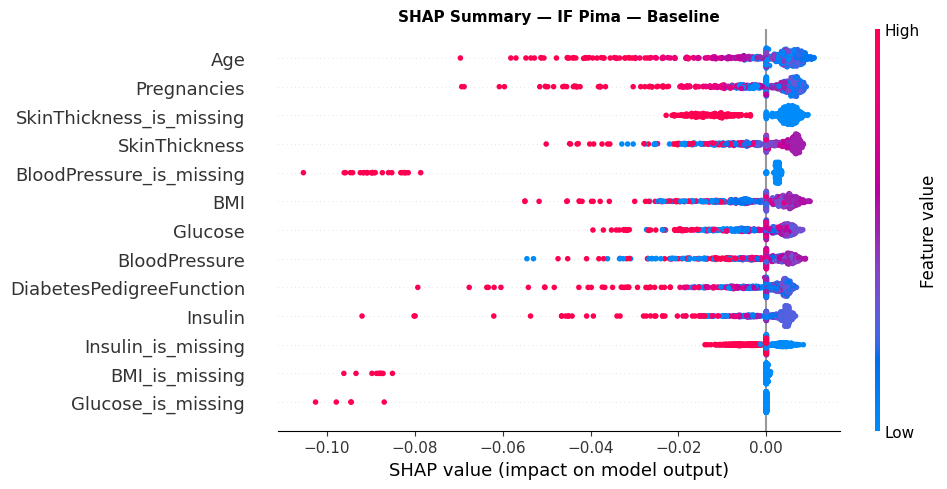

In [7]:
# IF Pima — SHAP baseline (establishes which features drive anomaly scores normally)
print('\n[SHAP] Computing baseline SHAP values for IF Pima...')
shap_if_p_base = run_shap_analysis(
    if_pima_ab.score_samples,
    data_pima['X_base_scaled'],
    data_pima['X_base_scaled'],
    'IF Pima — Baseline'
)

In [8]:
# IF Pima — Univariate abrupt drift (Glucose only)
X_test_raw_p_f = data_pima['X_test_raw'].copy()
for col in data_pima['continuous_cols']:
    X_test_raw_p_f[col] = X_test_raw_p_f[col].astype(float)

X_drifted_uni_raw_p  = apply_minmax_drift(X_test_raw_p_f, base_stats_pima, ['Glucose'],
                                            SHIFT_FACTOR, RANGE_FACTOR, verbose=True)
X_drifted_uni_sc_p   = apply_pipeline(X_drifted_uni_raw_p, data_pima)

print('\n--- IF Pima Abrupt Univariate Results ---')
# Denominator: zero-drift control on undrifted test set (X_test_scaled)
dr_if_p_uni = compute_dr(if_pima_ab, data_pima['X_test_scaled'],
                          X_drifted_uni_sc_p, label='IF Pima Univariate')

# K-S: undrifted test set vs drifted test set
run_ks_tests(data_pima['X_test_scaled'], X_drifted_uni_sc_p,
             'IF Pima Univariate', ['Glucose', 'BMI', 'Age'])



Affine drift: shift_factor=0.4, range_factor=1.5
Features: ['Glucose']
  Glucose: mean 122.10->134.76 (+10.4%)  std 30.59->45.89 (+50.0%)

--- IF Pima Abrupt Univariate Results ---
  [IF Pima Univariate] baseline=16.9%  drifted=22.9%  DR=1.359x
  K-S tests — IF Pima Univariate:
    Glucose : KS=0.1991  p=2.02e-04  → DIFFERENT ✓
    BMI     : KS=0.0000  p=1.00e+00  → unchanged (ctrl) ✓
    Age     : KS=0.0000  p=1.00e+00  → unchanged (ctrl) ✓



[SHAP] Univariate drift attribution:
  Computing SHAP for: IF Pima — Univariate Drift (Glucose) (k-means background k=100)


  0%|          | 0/231 [00:00<?, ?it/s]

  Plotting SHAP summary — IF Pima — Univariate Drift (Glucose)


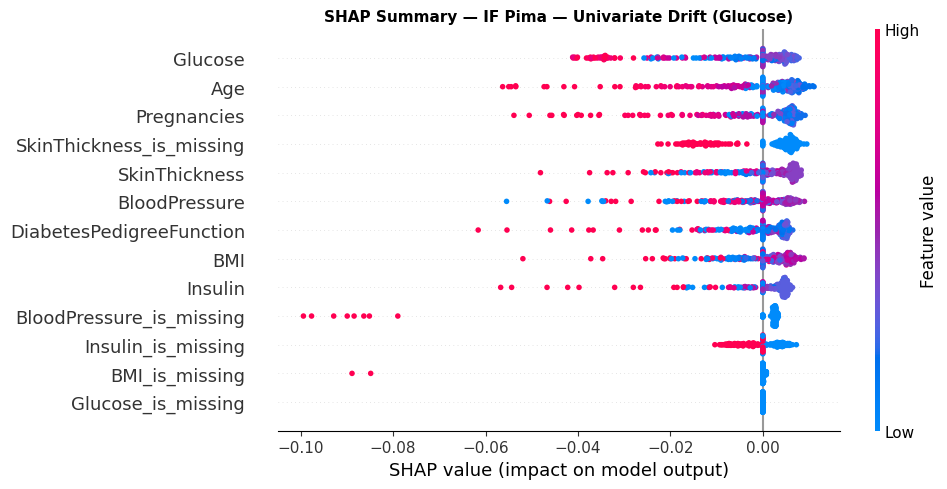

In [9]:
# SHAP — IF Pima univariate drift
print('\n[SHAP] Univariate drift attribution:')
shap_if_p_uni = run_shap_analysis(
    if_pima_ab.score_samples,
    data_pima['X_base_scaled'],
    X_drifted_uni_sc_p,
    'IF Pima — Univariate Drift (Glucose)'
)

In [9]:
# IF Pima — Multivariate abrupt drift
X_drifted_multi_raw_p = apply_minmax_drift(X_test_raw_p_f, base_stats_pima,
                                            DRIFT_FEATURES_MULTI,
                                            SHIFT_FACTOR, RANGE_FACTOR, verbose=True)
X_drifted_multi_sc_p  = apply_pipeline(X_drifted_multi_raw_p, data_pima)

print('\n--- IF Pima Abrupt Multivariate Results ---')
# Denominator: zero-drift control on undrifted test set (X_test_scaled)
dr_if_p_multi = compute_dr(if_pima_ab, data_pima['X_test_scaled'],
                            X_drifted_multi_sc_p, label='IF Pima Multivariate')

# K-S: undrifted test set vs drifted test set
run_ks_tests(data_pima['X_test_scaled'], X_drifted_multi_sc_p,
             'IF Pima Multivariate', DRIFT_FEATURES_MULTI)



Affine drift: shift_factor=0.4, range_factor=1.5
Features: ['Glucose', 'BMI', 'Age']
  Glucose: mean 122.10->134.76 (+10.4%)  std 30.59->45.89 (+50.0%)
  BMI: mean 32.69->29.02 (-11.2%)  std 6.46->9.68 (+50.0%)
  Age: mean 33.60->27.30 (-18.7%)  std 11.92->17.87 (+50.0%)

--- IF Pima Abrupt Multivariate Results ---
  [IF Pima Multivariate] baseline=16.9%  drifted=28.6%  DR=1.692x
  K-S tests — IF Pima Multivariate:
    Glucose : KS=0.1991  p=2.02e-04  → DIFFERENT ✓
    BMI     : KS=0.2727  p=5.76e-08  → DIFFERENT ✓
    Age     : KS=0.5108  p=8.15e-28  → DIFFERENT ✓



[SHAP] Multivariate drift attribution:
  Computing SHAP for: IF Pima — Multivariate Drift (Glu+BMI+Age) (k-means background k=100)


  0%|          | 0/231 [00:00<?, ?it/s]

  Plotting SHAP summary — IF Pima — Multivariate Drift (Glu+BMI+Age)


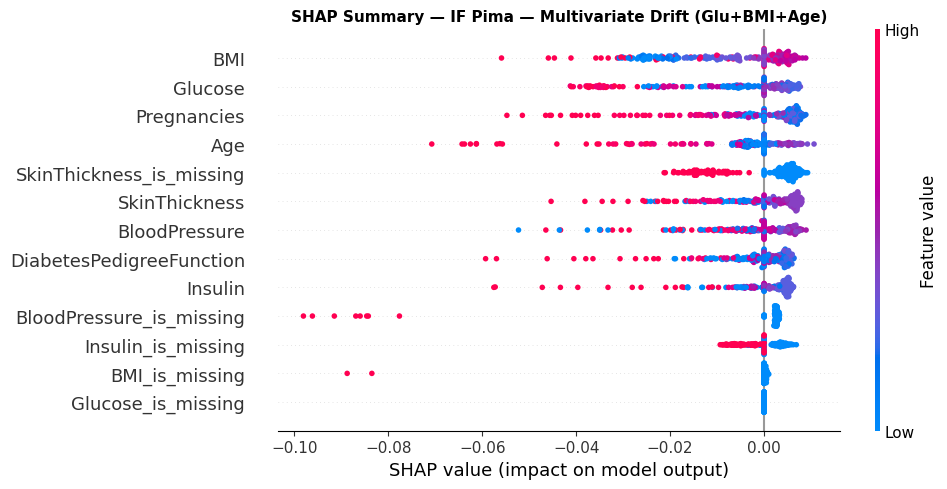

In [11]:
# SHAP — IF Pima multivariate drift
print('\n[SHAP] Multivariate drift attribution:')
shap_if_p_multi = run_shap_analysis(
    if_pima_ab.score_samples,
    data_pima['X_base_scaled'],
    X_drifted_multi_sc_p,
    'IF Pima — Multivariate Drift (Glu+BMI+Age)'
)

In [10]:
# ──────────────────────────────────────────────────────────────────
# PIMA — OCSVM ABRUPT DRIFT  (nu=0.2, gamma='scale')
# ──────────────────────────────────────────────────────────────────
print('\n--- OCSVM Abrupt Drift (Pima) ---')
print("nu=0.2, gamma=scale  (matches IF contamination=0.2)")

ocsvm_pima_ab = OneClassSVM(kernel='rbf', nu=0.2, gamma='scale')
ocsvm_pima_ab.fit(data_pima['X_base_scaled'])
# Zero-drift control: rate on undrifted TEST set (n=231) — matches paper denominator
baseline_rate_ocsvm_p = (ocsvm_pima_ab.predict(data_pima['X_test_scaled']) == -1).mean()
print(f'OCSVM Pima zero-drift control rate (test set, n=231): {baseline_rate_ocsvm_p:.1%}')



--- OCSVM Abrupt Drift (Pima) ---
nu=0.2, gamma=scale  (matches IF contamination=0.2)
OCSVM Pima zero-drift control rate (test set, n=231): 22.1%



[SHAP] Computing baseline SHAP values for OCSVM Pima...
  Computing SHAP for: OCSVM Pima — Baseline (k-means background k=100)


  0%|          | 0/537 [00:00<?, ?it/s]

  Plotting SHAP summary — OCSVM Pima — Baseline


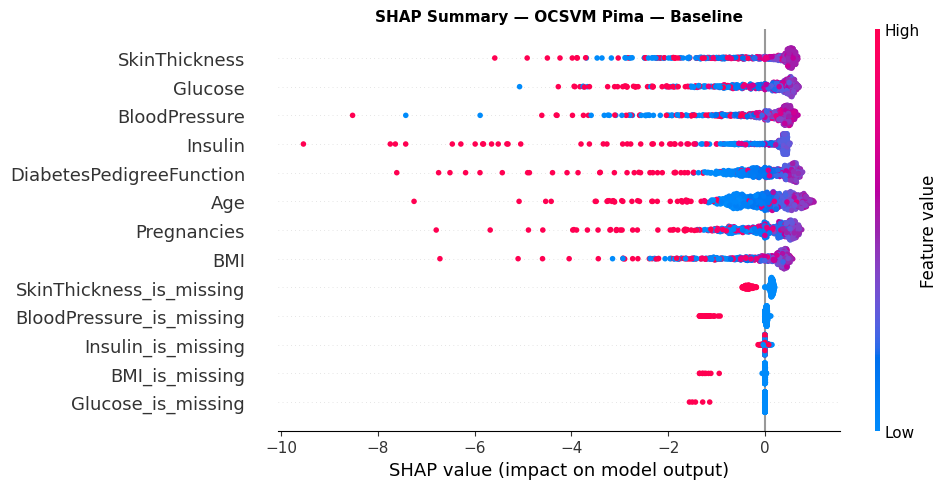

In [13]:
# SHAP — OCSVM Pima baseline
print('\n[SHAP] Computing baseline SHAP values for OCSVM Pima...')
shap_ocsvm_p_base = run_shap_analysis(
    ocsvm_pima_ab.decision_function,
    data_pima['X_base_scaled'],
    data_pima['X_base_scaled'],
    'OCSVM Pima — Baseline'
)


--- OCSVM Pima Abrupt Univariate Results ---
  [OCSVM Pima Univariate] baseline=22.1%  drifted=31.2%  DR=1.412x
  K-S tests — OCSVM Pima Univariate:
    Glucose : KS=0.1991  p=2.02e-04  → DIFFERENT ✓
    BMI     : KS=0.0000  p=1.00e+00  → unchanged (ctrl) ✓
    Age     : KS=0.0000  p=1.00e+00  → unchanged (ctrl) ✓

[SHAP] Univariate drift attribution:
  Computing SHAP for: OCSVM Pima — Univariate Drift (Glucose) (k-means background k=100)


  0%|          | 0/231 [00:00<?, ?it/s]

  Plotting SHAP summary — OCSVM Pima — Univariate Drift (Glucose)


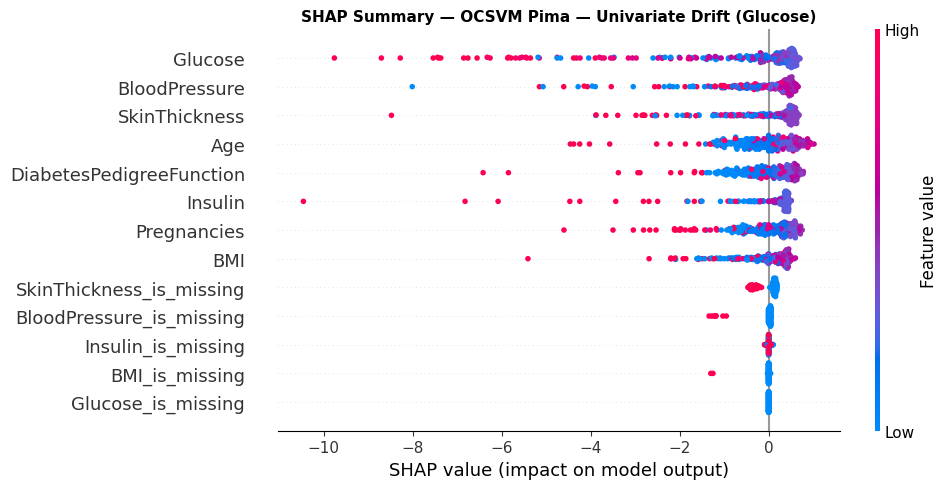

In [11]:
# OCSVM Pima — Univariate abrupt drift
print('\n--- OCSVM Pima Abrupt Univariate Results ---')
# Denominator: zero-drift control on undrifted test set (X_test_scaled)
dr_ocsvm_p_uni = compute_dr(ocsvm_pima_ab, data_pima['X_test_scaled'],
                              X_drifted_uni_sc_p, label='OCSVM Pima Univariate')

# K-S: undrifted test set vs drifted test set
run_ks_tests(data_pima['X_test_scaled'], X_drifted_uni_sc_p,
             'OCSVM Pima Univariate', ['Glucose', 'BMI', 'Age'])

print('\n[SHAP] Univariate drift attribution:')
shap_ocsvm_p_uni = run_shap_analysis(
    ocsvm_pima_ab.decision_function,
    data_pima['X_base_scaled'],
    X_drifted_uni_sc_p,
    'OCSVM Pima — Univariate Drift (Glucose)'
)



--- OCSVM Pima Abrupt Multivariate Results ---
  [OCSVM Pima Multivariate] baseline=22.1%  drifted=61.9%  DR=2.804x
  K-S tests — OCSVM Pima Multivariate:
    Glucose : KS=0.1991  p=2.02e-04  → DIFFERENT ✓
    BMI     : KS=0.2727  p=5.76e-08  → DIFFERENT ✓
    Age     : KS=0.5108  p=8.15e-28  → DIFFERENT ✓

[SHAP] Multivariate drift attribution:
  Computing SHAP for: OCSVM Pima — Multivariate Drift (Glu+BMI+Age) (k-means background k=100)


  0%|          | 0/231 [00:00<?, ?it/s]

  Plotting SHAP summary — OCSVM Pima — Multivariate Drift (Glu+BMI+Age)


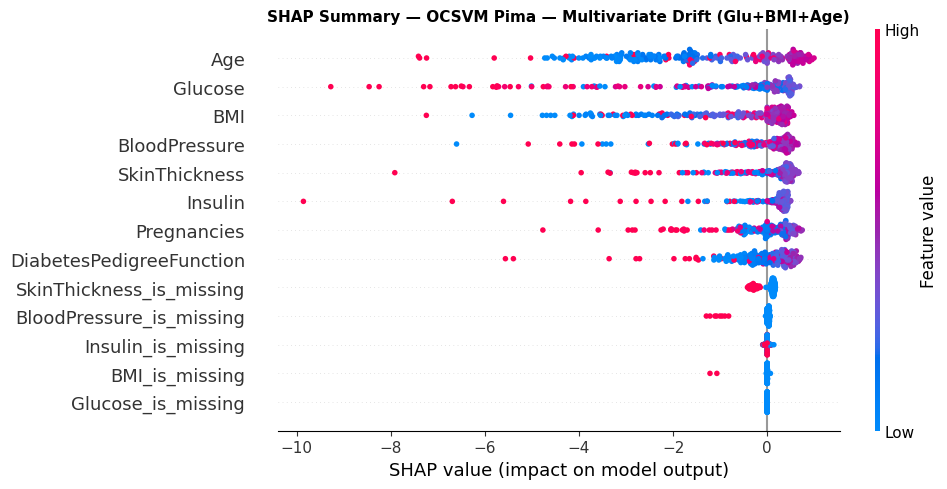

In [13]:
# OCSVM Pima — Multivariate abrupt drift
print('\n--- OCSVM Pima Abrupt Multivariate Results ---')
# Denominator: zero-drift control on undrifted test set (X_test_scaled)
dr_ocsvm_p_multi = compute_dr(ocsvm_pima_ab, data_pima['X_test_scaled'],
                               X_drifted_multi_sc_p, label='OCSVM Pima Multivariate')

# K-S: undrifted test set vs drifted test set
run_ks_tests(data_pima['X_test_scaled'], X_drifted_multi_sc_p,
             'OCSVM Pima Multivariate', DRIFT_FEATURES_MULTI)

print('\n[SHAP] Multivariate drift attribution:')
shap_ocsvm_p_multi = run_shap_analysis(
    ocsvm_pima_ab.decision_function,
    data_pima['X_base_scaled'],
    X_drifted_multi_sc_p,
    'OCSVM Pima — Multivariate Drift (Glu+BMI+Age)'
)


In [14]:
# ── PIMA — Algorithm comparison (abrupt) ─────────────────────────
print('\n=== Pima Abrupt Drift: Algorithm Comparison ===')
comp_pima_abrupt = pd.DataFrame([
    {'Scenario': 'Univariate',   'IF DR': round(dr_if_p_uni['detection_ratio'],3),
     'OCSVM DR': round(dr_ocsvm_p_uni['detection_ratio'],3)},
    {'Scenario': 'Multivariate', 'IF DR': round(dr_if_p_multi['detection_ratio'],3),
     'OCSVM DR': round(dr_ocsvm_p_multi['detection_ratio'],3)},
])
comp_pima_abrupt['Advantage (abrupt)'] = comp_pima_abrupt.apply(
    lambda r: 'OCSVM' if r['OCSVM DR'] > r['IF DR'] else 'IF', axis=1)
display(comp_pima_abrupt)

# Store
for scenario, dr_if, dr_ocsvm in [
    ('Univariate',   dr_if_p_uni,   dr_ocsvm_p_uni),
    ('Multivariate', dr_if_p_multi, dr_ocsvm_p_multi),
]:
    all_results_rows.append(dict(dataset='Pima', algorithm='IF', scenario=scenario,
        drift_type='Abrupt', drift_amount='affine(delta=0.4,sigma=1.5)',
        baseline_rate=round(dr_if['baseline_rate'],4),
        drifted_rate=round(dr_if['drifted_rate'],4),
        detection_ratio=round(dr_if['detection_ratio'],4)))
    all_results_rows.append(dict(dataset='Pima', algorithm='OCSVM', scenario=scenario,
        drift_type='Abrupt', drift_amount='affine(delta=0.4,sigma=1.5)',
        baseline_rate=round(dr_ocsvm['baseline_rate'],4),
        drifted_rate=round(dr_ocsvm['drifted_rate'],4),
        detection_ratio=round(dr_ocsvm['detection_ratio'],4)))
print('Pima abrupt results stored.')


=== Pima Abrupt Drift: Algorithm Comparison ===


,Scenario,IF DR,OCSVM DR,Advantage (abrupt)
0,Univariate,1.359,1.412,OCSVM
1,Multivariate,1.692,2.804,OCSVM


Pima abrupt results stored.


In [15]:
# ================================================================
# SECTION 2 — FRANKFURT HOSPITAL GLUCOSE DATASET (FHGD)
# ================================================================
DS = 'FHGD'
print(f'Loading and preprocessing {DS}...')
data_fhgd = preprocess_dataset(DATASET_CONFIGS[DS]['step1_path'])
print(f'  Baseline: {len(data_fhgd["X_base_raw"]):,}  Test: {len(data_fhgd["X_test_raw"]):,}')

print('\nBaseline feature stats (for affine drift):')
base_stats_fhgd = compute_base_stats(data_fhgd['X_base_raw'], DRIFT_FEATURES_MULTI)

Loading and preprocessing FHGD...
  Baseline: 1,400  Test: 600

Baseline feature stats (for affine drift):
  Glucose: f_min=44.000, f_max=199.000
  BMI: f_min=18.200, f_max=67.100
  Age: f_min=21.000, f_max=81.000


In [16]:
# ──────────────────────────────────────────────────────────────────
# FHGD — ISOLATION FOREST ABRUPT DRIFT
# ──────────────────────────────────────────────────────────────────
print('\n--- Isolation Forest Abrupt Drift (FHGD) ---')
if_fhgd_ab = IsolationForest(n_estimators=100, contamination=0.2, random_state=42, n_jobs=-1)
if_fhgd_ab.fit(data_fhgd['X_base_scaled'])
# Zero-drift control: rate on undrifted TEST set (n=600) — matches paper denominator
baseline_rate_if_f = (if_fhgd_ab.predict(data_fhgd['X_test_scaled']) == -1).mean()
print(f'IF FHGD zero-drift control rate (test set, n=600): {baseline_rate_if_f:.1%}')

# Prepare drifted test sets
X_test_raw_f_f = data_fhgd['X_test_raw'].copy()
for col in data_fhgd['continuous_cols']:
    X_test_raw_f_f[col] = X_test_raw_f_f[col].astype(float)

X_drifted_uni_raw_f   = apply_minmax_drift(X_test_raw_f_f, base_stats_fhgd,
                            ['Glucose'], SHIFT_FACTOR, RANGE_FACTOR, verbose=True)
X_drifted_uni_sc_f    = apply_pipeline(X_drifted_uni_raw_f, data_fhgd)

X_drifted_multi_raw_f = apply_minmax_drift(X_test_raw_f_f, base_stats_fhgd,
                            DRIFT_FEATURES_MULTI, SHIFT_FACTOR, RANGE_FACTOR, verbose=True)
X_drifted_multi_sc_f  = apply_pipeline(X_drifted_multi_raw_f, data_fhgd)



--- Isolation Forest Abrupt Drift (FHGD) ---
IF FHGD zero-drift control rate (test set, n=600): 22.5%

Affine drift: shift_factor=0.4, range_factor=1.5
Features: ['Glucose']
  Glucose: mean 122.36->135.14 (+10.4%)  std 30.51->45.76 (+50.0%)

Affine drift: shift_factor=0.4, range_factor=1.5
Features: ['Glucose', 'BMI', 'Age']
  Glucose: mean 122.36->135.14 (+10.4%)  std 30.51->45.76 (+50.0%)
  BMI: mean 32.99->29.46 (-10.7%)  std 7.93->11.89 (+50.0%)
  Age: mean 33.03->26.44 (-19.9%)  std 11.72->17.58 (+50.0%)



[SHAP] Computing baseline SHAP values for IF FHGD...
  Computing SHAP for: IF FHGD — Baseline (k-means background k=100)


  0%|          | 0/1400 [00:00<?, ?it/s]

  Plotting SHAP summary — IF FHGD — Baseline


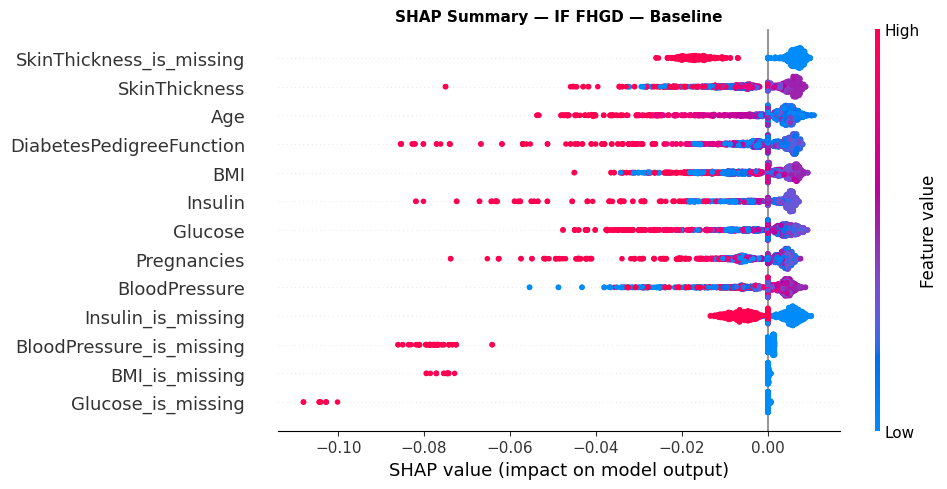

In [19]:
# IF FHGD — SHAP baseline
print('\n[SHAP] Computing baseline SHAP values for IF FHGD...')
shap_if_f_base = run_shap_analysis(
    if_fhgd_ab.score_samples,
    data_fhgd['X_base_scaled'],
    data_fhgd['X_base_scaled'],
    'IF FHGD — Baseline'
)

In [17]:
# IF FHGD — Detection ratios
print('\n--- IF FHGD Abrupt Results ---')
# Denominator: zero-drift control on undrifted test set (X_test_scaled)
dr_if_f_uni   = compute_dr(if_fhgd_ab, data_fhgd['X_test_scaled'],
                            X_drifted_uni_sc_f,   label='IF FHGD Univariate')
dr_if_f_multi = compute_dr(if_fhgd_ab, data_fhgd['X_test_scaled'],
                            X_drifted_multi_sc_f, label='IF FHGD Multivariate')

print('\nK-S Validation — IF FHGD:')
# K-S: undrifted test set vs drifted test set
run_ks_tests(data_fhgd['X_test_scaled'], X_drifted_uni_sc_f,
             'IF FHGD Univariate', ['Glucose', 'BMI', 'Age'])
run_ks_tests(data_fhgd['X_test_scaled'], X_drifted_multi_sc_f,
             'IF FHGD Multivariate', DRIFT_FEATURES_MULTI)



--- IF FHGD Abrupt Results ---
  [IF FHGD Univariate] baseline=22.5%  drifted=28.8%  DR=1.281x
  [IF FHGD Multivariate] baseline=22.5%  drifted=35.8%  DR=1.593x

K-S Validation — IF FHGD:
  K-S tests — IF FHGD Univariate:
    Glucose : KS=0.1600  p=4.05e-07  → DIFFERENT ✓
    BMI     : KS=0.0000  p=1.00e+00  → unchanged (ctrl) ✓
    Age     : KS=0.0000  p=1.00e+00  → unchanged (ctrl) ✓
  K-S tests — IF FHGD Multivariate:
    Glucose : KS=0.1600  p=4.05e-07  → DIFFERENT ✓
    BMI     : KS=0.2467  p=1.97e-16  → DIFFERENT ✓
    Age     : KS=0.5283  p=6.39e-77  → DIFFERENT ✓



[SHAP] IF FHGD drift attribution:
  Computing SHAP for: IF FHGD — Univariate (Glucose) (k-means background k=100)


  0%|          | 0/600 [00:00<?, ?it/s]

  Plotting SHAP summary — IF FHGD — Univariate (Glucose)


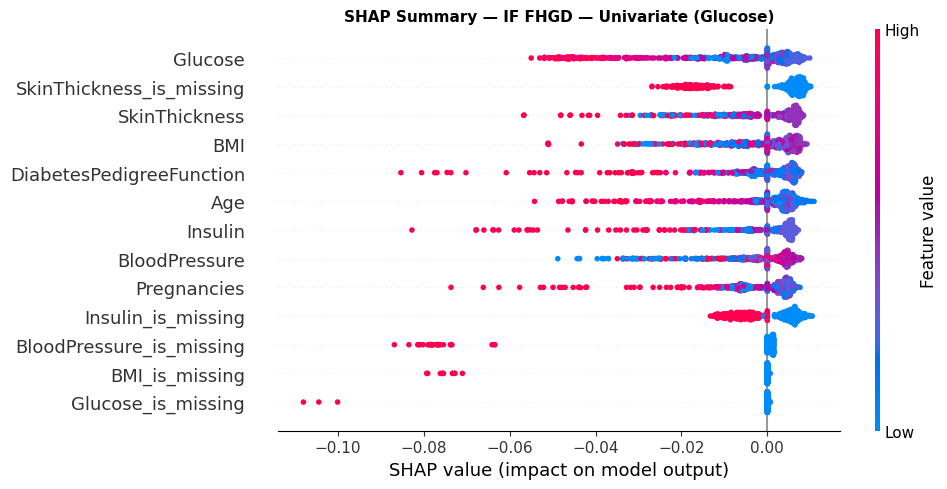

  Computing SHAP for: IF FHGD — Multivariate (Glu+BMI+Age) (k-means background k=100)


  0%|          | 0/600 [00:00<?, ?it/s]

  Plotting SHAP summary — IF FHGD — Multivariate (Glu+BMI+Age)


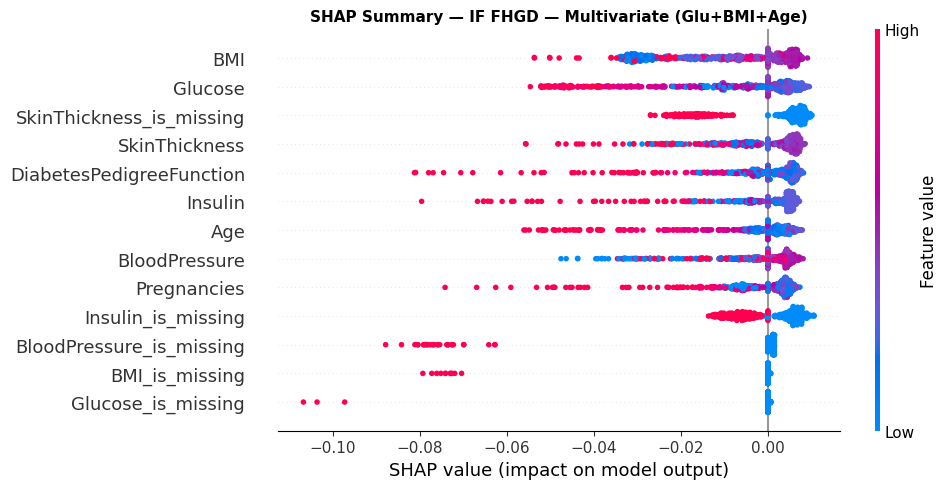

In [21]:
# SHAP — IF FHGD drift (Figure 5 in paper)
print('\n[SHAP] IF FHGD drift attribution:')
shap_if_f_uni = run_shap_analysis(
    if_fhgd_ab.score_samples, data_fhgd['X_base_scaled'],
    X_drifted_uni_sc_f, 'IF FHGD — Univariate (Glucose)'
)
shap_if_f_multi = run_shap_analysis(
    if_fhgd_ab.score_samples, data_fhgd['X_base_scaled'],
    X_drifted_multi_sc_f, 'IF FHGD — Multivariate (Glu+BMI+Age)'
)

In [18]:
# ──────────────────────────────────────────────────────────────────
# FHGD — OCSVM ABRUPT DRIFT
# ──────────────────────────────────────────────────────────────────
print('\n--- OCSVM Abrupt Drift (FHGD) ---')
ocsvm_fhgd_ab = OneClassSVM(kernel='rbf', nu=0.2, gamma='scale')
ocsvm_fhgd_ab.fit(data_fhgd['X_base_scaled'])
# Zero-drift control: rate on undrifted TEST set (n=600) — matches paper denominator
baseline_rate_ocsvm_f = (ocsvm_fhgd_ab.predict(data_fhgd['X_test_scaled']) == -1).mean()
print(f'OCSVM FHGD zero-drift control rate (test set, n=600): {baseline_rate_ocsvm_f:.1%}')



--- OCSVM Abrupt Drift (FHGD) ---
OCSVM FHGD zero-drift control rate (test set, n=600): 21.8%



[SHAP] Computing baseline SHAP values for OCSVM FHGD...
  Computing SHAP for: OCSVM FHGD — Baseline (k-means background k=100)


  0%|          | 0/1400 [00:00<?, ?it/s]

  Plotting SHAP summary — OCSVM FHGD — Baseline


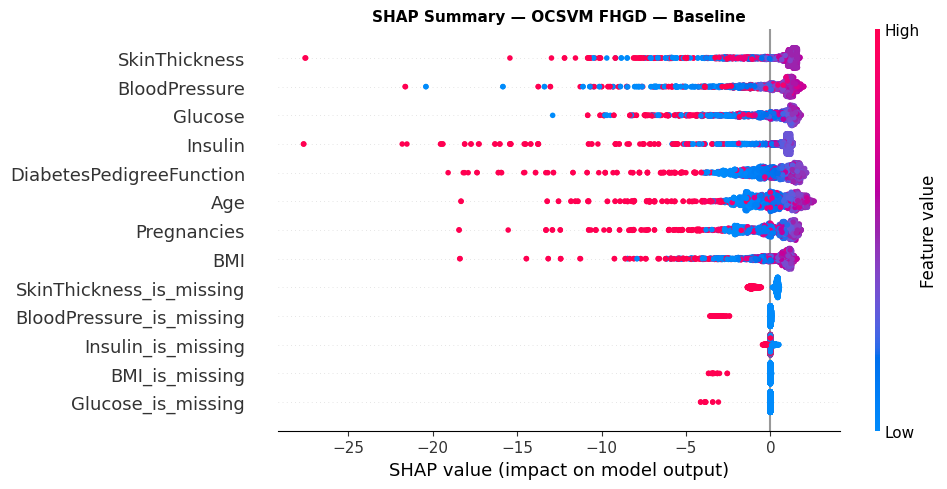

In [23]:
# SHAP — OCSVM FHGD baseline
print('\n[SHAP] Computing baseline SHAP values for OCSVM FHGD...')
shap_ocsvm_f_base = run_shap_analysis(
    ocsvm_fhgd_ab.decision_function,
    data_fhgd['X_base_scaled'],
    data_fhgd['X_base_scaled'],
    'OCSVM FHGD — Baseline'
)

In [19]:
# OCSVM FHGD — Detection ratios (headline results from paper)
print('\n--- OCSVM FHGD Abrupt Results ---')
# Denominator: zero-drift control on undrifted test set (X_test_scaled)
dr_ocsvm_f_uni   = compute_dr(ocsvm_fhgd_ab, data_fhgd['X_test_scaled'],
                               X_drifted_uni_sc_f,   label='OCSVM FHGD Univariate')
dr_ocsvm_f_multi = compute_dr(ocsvm_fhgd_ab, data_fhgd['X_test_scaled'],
                               X_drifted_multi_sc_f, label='OCSVM FHGD Multivariate')

print(f'\n*** HEADLINE RESULT: OCSVM FHGD Multivariate DR = {dr_ocsvm_f_multi["detection_ratio"]:.3f}x ***')
print(f'    ({int(dr_ocsvm_f_multi["drifted_rate"]*len(data_fhgd["X_test_raw"]))} / '
      f'{len(data_fhgd["X_test_raw"])} samples flagged as anomalous)')

print('\nK-S Validation — OCSVM FHGD:')
# K-S: undrifted test set vs drifted test set
run_ks_tests(data_fhgd['X_test_scaled'], X_drifted_uni_sc_f,
             'OCSVM FHGD Univariate', ['Glucose', 'BMI', 'Age'])
run_ks_tests(data_fhgd['X_test_scaled'], X_drifted_multi_sc_f,
             'OCSVM FHGD Multivariate', DRIFT_FEATURES_MULTI)



--- OCSVM FHGD Abrupt Results ---
  [OCSVM FHGD Univariate] baseline=21.8%  drifted=32.8%  DR=1.504x
  [OCSVM FHGD Multivariate] baseline=21.8%  drifted=64.5%  DR=2.954x

*** HEADLINE RESULT: OCSVM FHGD Multivariate DR = 2.954x ***
    (387 / 600 samples flagged as anomalous)

K-S Validation — OCSVM FHGD:
  K-S tests — OCSVM FHGD Univariate:
    Glucose : KS=0.1600  p=4.05e-07  → DIFFERENT ✓
    BMI     : KS=0.0000  p=1.00e+00  → unchanged (ctrl) ✓
    Age     : KS=0.0000  p=1.00e+00  → unchanged (ctrl) ✓
  K-S tests — OCSVM FHGD Multivariate:
    Glucose : KS=0.1600  p=4.05e-07  → DIFFERENT ✓
    BMI     : KS=0.2467  p=1.97e-16  → DIFFERENT ✓
    Age     : KS=0.5283  p=6.39e-77  → DIFFERENT ✓



[SHAP] OCSVM FHGD drift attribution:
  Computing SHAP for: OCSVM FHGD — Univariate (Glucose) (k-means background k=100)


  0%|          | 0/600 [00:00<?, ?it/s]

  Plotting SHAP summary — OCSVM FHGD — Univariate (Glucose)


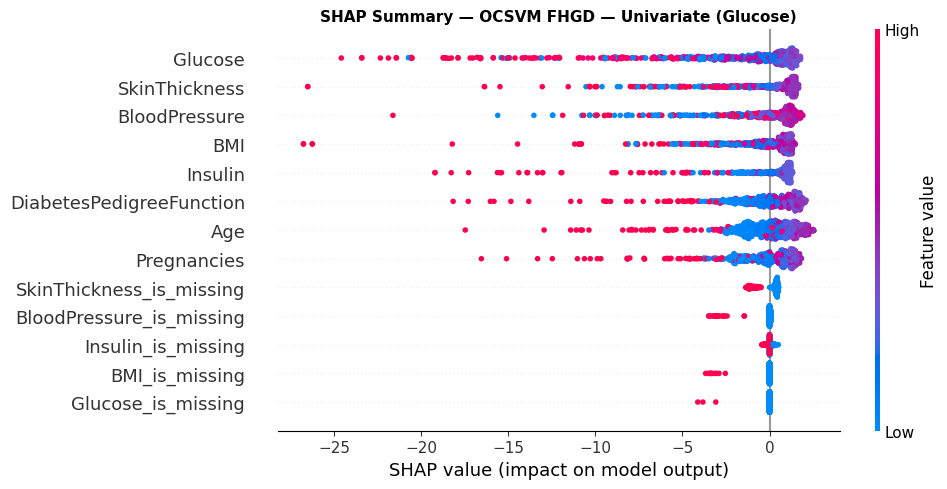

  Computing SHAP for: OCSVM FHGD — Multivariate (Glu+BMI+Age) (k-means background k=100)


  0%|          | 0/600 [00:00<?, ?it/s]

  Plotting SHAP summary — OCSVM FHGD — Multivariate (Glu+BMI+Age)


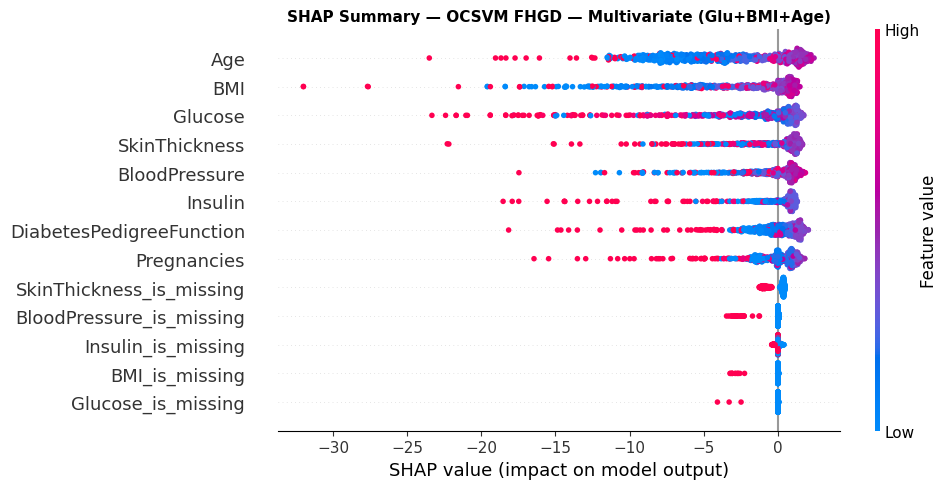

In [21]:
# SHAP — OCSVM FHGD drift (Figure 4 in paper)
print('\n[SHAP] OCSVM FHGD drift attribution:')
shap_ocsvm_f_uni = run_shap_analysis(
    ocsvm_fhgd_ab.decision_function, data_fhgd['X_base_scaled'],
    X_drifted_uni_sc_f, 'OCSVM FHGD — Univariate (Glucose)'
)
shap_ocsvm_f_multi = run_shap_analysis(
    ocsvm_fhgd_ab.decision_function, data_fhgd['X_base_scaled'],
    X_drifted_multi_sc_f, 'OCSVM FHGD — Multivariate (Glu+BMI+Age)'
)

In [20]:
# ── FHGD — Algorithm comparison ──────────────────────────────────
print('\n=== FHGD Abrupt Drift: Algorithm Comparison ===')
comp_fhgd_abrupt = pd.DataFrame([
    {'Scenario': 'Univariate',   'IF DR': round(dr_if_f_uni['detection_ratio'],3),
     'OCSVM DR': round(dr_ocsvm_f_uni['detection_ratio'],3)},
    {'Scenario': 'Multivariate', 'IF DR': round(dr_if_f_multi['detection_ratio'],3),
     'OCSVM DR': round(dr_ocsvm_f_multi['detection_ratio'],3)},
])
comp_fhgd_abrupt['Advantage (abrupt)'] = comp_fhgd_abrupt.apply(
    lambda r: 'OCSVM' if r['OCSVM DR'] > r['IF DR'] else 'IF', axis=1)
display(comp_fhgd_abrupt)

for scenario, dr_if, dr_ocsvm in [
    ('Univariate',   dr_if_f_uni,   dr_ocsvm_f_uni),
    ('Multivariate', dr_if_f_multi, dr_ocsvm_f_multi),
]:
    all_results_rows.append(dict(dataset='FHGD', algorithm='IF', scenario=scenario,
        drift_type='Abrupt', drift_amount='affine(delta=0.4,sigma=1.5)',
        baseline_rate=round(dr_if['baseline_rate'],4),
        drifted_rate=round(dr_if['drifted_rate'],4),
        detection_ratio=round(dr_if['detection_ratio'],4)))
    all_results_rows.append(dict(dataset='FHGD', algorithm='OCSVM', scenario=scenario,
        drift_type='Abrupt', drift_amount='affine(delta=0.4,sigma=1.5)',
        baseline_rate=round(dr_ocsvm['baseline_rate'],4),
        drifted_rate=round(dr_ocsvm['drifted_rate'],4),
        detection_ratio=round(dr_ocsvm['detection_ratio'],4)))
print('FHGD abrupt results stored.')


=== FHGD Abrupt Drift: Algorithm Comparison ===


,Scenario,IF DR,OCSVM DR,Advantage (abrupt)
0,Univariate,1.281,1.504,OCSVM
1,Multivariate,1.593,2.954,OCSVM


FHGD abrupt results stored.


In [21]:
# ================================================================
# SECTION 3 — SAVE RESULTS & CROSS-COHORT SUMMARY
# ================================================================
results_df = pd.DataFrame(all_results_rows)
out_path   = RESULTS_DIR / 'abrupt_drift_results.csv'
results_df.to_csv(out_path, index=False)
print(f'Abrupt drift results saved -> {out_path}')
display(results_df.round(3))

Abrupt drift results saved -> data\results\abrupt_drift_results.csv


,dataset,algorithm,scenario,drift_type,drift_amount,baseline_rate,drifted_rate,detection_ratio
0,Pima,IF,Univariate,Abrupt,"affine(delta=0.4,sigma=1.5)",0.169,0.229,1.359
1,Pima,OCSVM,Univariate,Abrupt,"affine(delta=0.4,sigma=1.5)",0.221,0.312,1.412
2,Pima,IF,Multivariate,Abrupt,"affine(delta=0.4,sigma=1.5)",0.169,0.286,1.692
3,Pima,OCSVM,Multivariate,Abrupt,"affine(delta=0.4,sigma=1.5)",0.221,0.619,2.804
4,FHGD,IF,Univariate,Abrupt,"affine(delta=0.4,sigma=1.5)",0.225,0.288,1.282
5,FHGD,OCSVM,Univariate,Abrupt,"affine(delta=0.4,sigma=1.5)",0.218,0.328,1.504
6,FHGD,IF,Multivariate,Abrupt,"affine(delta=0.4,sigma=1.5)",0.225,0.358,1.593
7,FHGD,OCSVM,Multivariate,Abrupt,"affine(delta=0.4,sigma=1.5)",0.218,0.645,2.954


In [22]:
# Cross-cohort comparison (algorithm-morphology inversion — key finding)
print('\n=== ABRUPT DRIFT: CROSS-COHORT COMPARISON ===')
pivot = results_df.pivot_table(index=['dataset','scenario'], columns='algorithm',
                                values='detection_ratio').round(3)
pivot['Leading'] = pivot.apply(lambda r: 'OCSVM' if r.get('OCSVM',0) > r.get('IF',0) else 'IF', axis=1)
display(pivot)

print('\nAbrupt drift notebook complete.')
print('Results saved to data/results/abrupt_drift_results.csv')
print('Next step: run 04_Cross_Cohort_Analysis.ipynb')


=== ABRUPT DRIFT: CROSS-COHORT COMPARISON ===


algorithm                IF  OCSVM Leading
dataset scenario                          
FHGD    Multivariate  1.593  2.954   OCSVM
        Univariate    1.282  1.504   OCSVM
Pima    Multivariate  1.692  2.804   OCSVM
        Univariate    1.359  1.412   OCSVM


Abrupt drift notebook complete.
Results saved to data/results/abrupt_drift_results.csv
Next step: run 04_Cross_Cohort_Analysis.ipynb
